## XGBoost Model Training, Evaluation

In [1]:
# Load the saved model datasets
import pandas as pd
from pathlib import Path

MODEL_DATA_PATH = Path("../model_datasets")

X_train = pd.read_parquet(MODEL_DATA_PATH / "X_train_scaled.parquet")
X_val   = pd.read_parquet(MODEL_DATA_PATH / "X_val_scaled.parquet")
X_test  = pd.read_parquet(MODEL_DATA_PATH / "X_test_scaled.parquet")

y_train = pd.read_parquet(MODEL_DATA_PATH / "y_train.parquet")["optimal_bucket_encoded"]
y_val   = pd.read_parquet(MODEL_DATA_PATH / "y_val.parquet")["optimal_bucket_encoded"]
y_test  = pd.read_parquet(MODEL_DATA_PATH / "y_test.parquet")["optimal_bucket_encoded"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (33736, 53) y_train: (33736,)
X_val: (5010, 53) y_val: (5010,)
X_test: (5020, 53) y_test: (5020,)


In [2]:
print("Train class distribution:")
print(y_train.value_counts().sort_index())

num_classes = y_train.nunique()
print("Number of classes:", num_classes)

Train class distribution:
optimal_bucket_encoded
0     4396
1     6190
2    12557
3     3170
4      713
5     3728
6     2982
Name: count, dtype: int64
Number of classes: 7



Train Dataset Distribution (Before Correction):
                        count  percentage (%)
optimal_bucket_encoded                       
0                        4396           13.03
1                        6190           18.35
2                       12557           37.22
3                        3170            9.40
4                         713            2.11
5                        3728           11.05
6                        2982            8.84


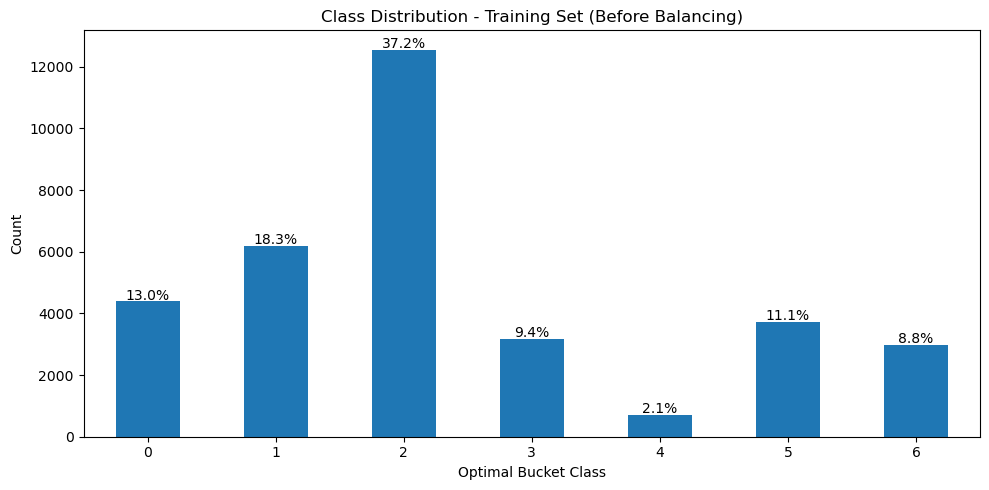

Imbalance Ratio (max/min): 17.61


In [3]:

#  Show train distribution BEFORE correction


import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()
class_pct = (class_counts / len(y_train) * 100).round(2)

dist_df = pd.DataFrame({
    "count": class_counts,
    "percentage (%)": class_pct
})

print("\nTrain Dataset Distribution (Before Correction):")
print(dist_df)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution - Training Set (Before Balancing)")
plt.xlabel("Optimal Bucket Class")
plt.ylabel("Count")
plt.xticks(rotation=0)

for i, v in enumerate(class_counts):
    plt.text(i, v + 50, f"{(v/len(y_train)*100):.1f}%", ha='center')

plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")

In [4]:


# Partial balancing on TRAIN ONLY (no shuffle)

train_df = X_train.copy()
train_df["optimal_bucket_encoded"] = y_train.values

print("\nOriginal train distribution:")
print(train_df["optimal_bucket_encoded"].value_counts().sort_index())

# Updated target counts for current 7-class setup
target_counts = {
    2: 9000,   # moderate undersample of dominant class
    4: 1500,   # moderate oversample of rarest class
    6: 2200    # moderate oversample of smaller class
}

balanced_parts = []

for cls, grp in train_df.groupby("optimal_bucket_encoded", sort=True):
    n_current = len(grp)

    if cls in target_counts:
        n_target = target_counts[cls]

        if n_target < n_current:
            grp_bal = grp.sample(n=n_target, random_state=42, replace=False)
            print(f"Class {cls}: undersampled {n_current} -> {n_target}")

        elif n_target > n_current:
            grp_bal = grp.sample(n=n_target, random_state=42, replace=True)
            print(f"Class {cls}: oversampled {n_current} -> {n_target}")

        else:
            grp_bal = grp.copy()
            print(f"Class {cls}: unchanged at {n_current}")

    else:
        grp_bal = grp.copy()
        print(f"Class {cls}: unchanged at {n_current}")

    balanced_parts.append(grp_bal)

train_balanced = pd.concat(balanced_parts, axis=0)

print("\nBalanced train distribution:")
print(train_balanced["optimal_bucket_encoded"].value_counts().sort_index())


Original train distribution:
optimal_bucket_encoded
0     4396
1     6190
2    12557
3     3170
4      713
5     3728
6     2982
Name: count, dtype: int64
Class 0: unchanged at 4396
Class 1: unchanged at 6190
Class 2: undersampled 12557 -> 9000
Class 3: unchanged at 3170
Class 4: oversampled 713 -> 1500
Class 5: unchanged at 3728
Class 6: undersampled 2982 -> 2200

Balanced train distribution:
optimal_bucket_encoded
0    4396
1    6190
2    9000
3    3170
4    1500
5    3728
6    2200
Name: count, dtype: int64


In [5]:
# split back
X_train_balanced = train_balanced.drop(columns=["optimal_bucket_encoded"]).copy()
y_train_balanced = train_balanced["optimal_bucket_encoded"].copy()

print("\nShapes after partial balancing:")
print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)


Shapes after partial balancing:
X_train_balanced: (30184, 53)
y_train_balanced: (30184,)


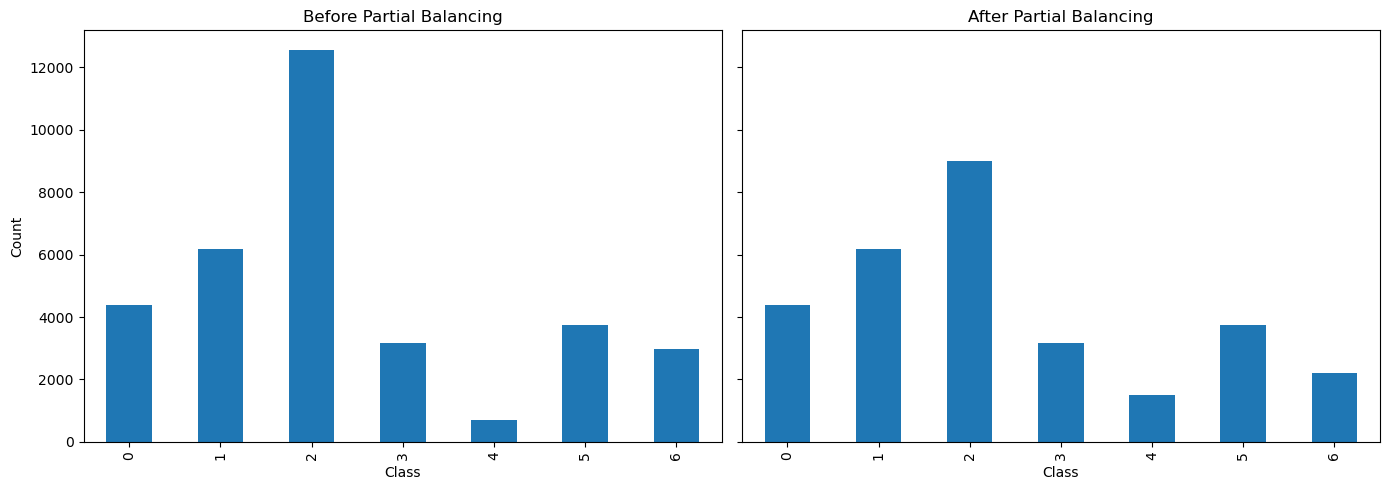

In [6]:

# optional comparison plot
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_balanced.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
before_counts.plot(kind="bar", ax=axes[0], title="Before Partial Balancing")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

after_counts.plot(kind="bar", ax=axes[1], title="After Partial Balancing")
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

In [7]:

#  Compute class weights AFTER balancing  


import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes_bal = np.sort(y_train_balanced.unique())

class_weights_bal = compute_class_weight(
    class_weight="balanced",
    classes=classes_bal,
    y=y_train_balanced
)

class_weight_dict_bal = dict(zip(classes_bal, class_weights_bal))

print("\nClass weights after balancing:")
print(class_weight_dict_bal)

sample_weight_train_balanced = y_train_balanced.map(class_weight_dict_bal).values


Class weights after balancing:
{np.int64(0): np.float64(0.9808917197452229), np.int64(1): np.float64(0.6966074313408723), np.int64(2): np.float64(0.4791111111111111), np.int64(3): np.float64(1.3602523659305994), np.int64(4): np.float64(2.8746666666666667), np.int64(5): np.float64(1.1566523605150214), np.int64(6): np.float64(1.96)}


In [8]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score

In [9]:

#  Optuna objective using BALANCED train + class weights

def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": num_classes,
        "n_estimators": trial.suggest_int("n_estimators", 200, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 25),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-1, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "mlogloss",
        "early_stopping_rounds": 50,
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_balanced,
        y_train_balanced,
        sample_weight=sample_weight_train_balanced,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_pred = model.predict(X_val)
    macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    return macro_f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\nBest trial score:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-03-23 12:25:57,222] A new study created in memory with name: no-name-2ab508c4-4e8a-48aa-8430-9bd3996d0222


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-23 12:25:58,682] Trial 0 finished with value: 0.1973482711130636 and parameters: {'n_estimators': 373, 'max_depth': 6, 'learning_rate': 0.0300133701188669, 'min_child_weight': 20, 'subsample': 0.627239827215202, 'colsample_bytree': 0.7956253971897937, 'gamma': 0.3676454832287974, 'reg_alpha': 0.0657420596410865, 'reg_lambda': 1.6842986324585505}. Best is trial 0 with value: 0.1973482711130636.
[I 2026-03-23 12:25:59,616] Trial 1 finished with value: 0.21305772409736393 and parameters: {'n_estimators': 240, 'max_depth': 2, 'learning_rate': 0.019815760294908096, 'min_child_weight': 10, 'subsample': 0.7649410340507893, 'colsample_bytree': 0.7184545038855717, 'gamma': 1.6041838288190653, 'reg_alpha': 0.15168626385263403, 'reg_lambda': 1.629288533354505}. Best is trial 1 with value: 0.21305772409736393.
[I 2026-03-23 12:26:00,465] Trial 2 finished with value: 0.21008953235348302 and parameters: {'n_estimators': 470, 'max_depth': 2, 'learning_rate': 0.019692634093165195, 'min_chil

In [10]:

#  Final tuned model using BALANCED train + class weights

best_params = study.best_params.copy()
best_params.update({
    "objective": "multi:softprob",
    "num_class": num_classes,
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "mlogloss",
    "early_stopping_rounds": 50
})

best_xgb_model = XGBClassifier(**best_params)

best_xgb_model.fit(
    X_train_balanced,
    y_train_balanced,
    sample_weight=sample_weight_train_balanced,
    eval_set=[(X_train_balanced, y_train_balanced), (X_val, y_val)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.655715715069085
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'mlogloss'


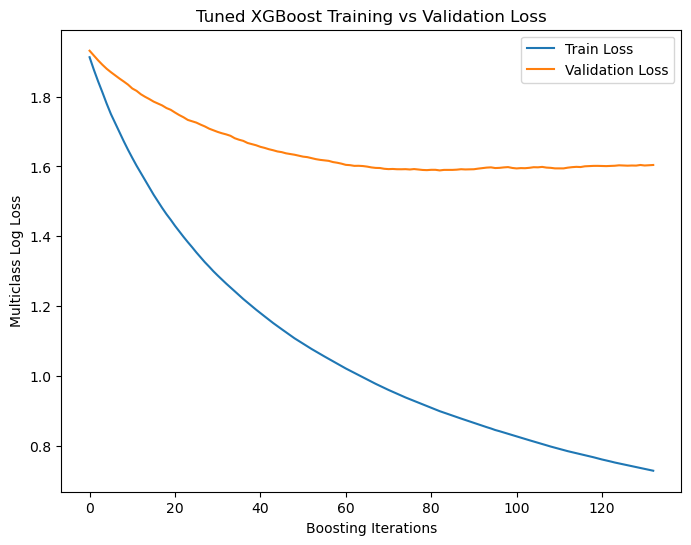

Best iteration: 82


In [11]:

#  Loss curves

results = best_xgb_model.evals_result()
train_loss = results["validation_0"]["mlogloss"]
val_loss = results["validation_1"]["mlogloss"]

plt.figure(figsize=(8, 6))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Boosting Iterations")
plt.ylabel("Multiclass Log Loss")
plt.title("Tuned XGBoost Training vs Validation Loss")
plt.legend()
plt.show()

print("Best iteration:", best_xgb_model.best_iteration)

In [12]:

#  Predictions

y_train_bal_pred = best_xgb_model.predict(X_train_balanced)
y_val_pred       = best_xgb_model.predict(X_val)
y_test_pred      = best_xgb_model.predict(X_test)


In [13]:

#  Evaluation

from sklearn.metrics import classification_report, confusion_matrix

print("\nTrain Accuracy:", accuracy_score(y_train_balanced, y_train_bal_pred))
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Train Macro F1:", f1_score(y_train_balanced, y_train_bal_pred, average="macro", zero_division=0))
print("Val Macro F1:", f1_score(y_val, y_val_pred, average="macro", zero_division=0))
print("Test Macro F1:", f1_score(y_test, y_test_pred, average="macro", zero_division=0))

print("Train Balanced Accuracy:", balanced_accuracy_score(y_train_balanced, y_train_bal_pred))
print("Val Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))

print("\nTest Classification Report")
print(classification_report(y_test, y_test_pred, zero_division=0))


Train Accuracy: 0.7743506493506493
Val Accuracy: 0.52375249500998
Test Accuracy: 0.348406374501992
Train Macro F1: 0.7814694346341607
Val Macro F1: 0.22068665104400803
Test Macro F1: 0.14641669376228508
Train Balanced Accuracy: 0.8088588282710251
Val Balanced Accuracy: 0.23535302665406757
Test Balanced Accuracy: 0.18059049099681015

Test Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       397
           1       0.00      0.00      0.00       140
           2       0.17      0.60      0.27       731
           3       0.00      0.00      0.00       366
           4       0.58      0.44      0.50      2668
           5       0.00      0.00      0.00        84
           6       0.29      0.23      0.26       634

    accuracy                           0.35      5020
   macro avg       0.15      0.18      0.15      5020
weighted avg       0.37      0.35      0.34      5020



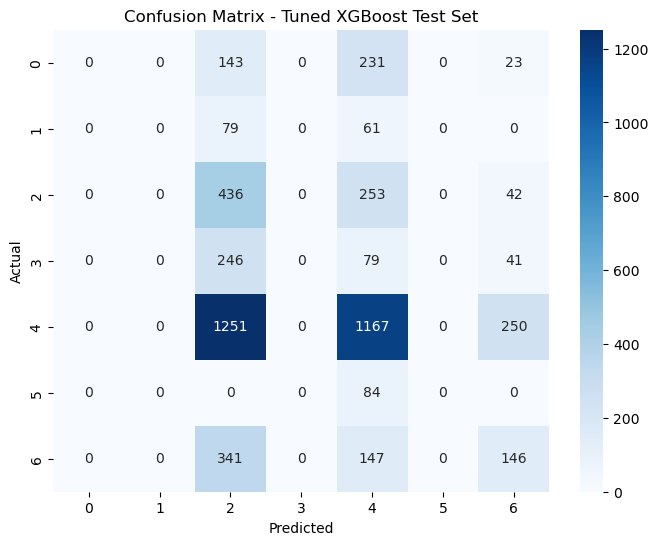

In [14]:
# =========================================================
# 10. Confusion matrix
# =========================================================
import seaborn as sns
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost Test Set")
plt.show()


Top 20 feature importances:
ebitda                                   0.094505
EPS                                      0.064160
50DayMovingAverage                       0.055826
dividendPayout                           0.051541
BookValue                                0.045347
52WeekLow                                0.043896
operatingIncome                          0.042827
symbol_AVGO                              0.035444
Beta                                     0.035315
totalCurrentAssets                       0.035246
symbol_GOOGL                             0.031697
200DayMovingAverage                      0.030811
cashAndCashEquivalentsAtCarryingValue    0.030671
longTermDebt                             0.030020
symbol_AMZN                              0.025569
grossProfit                              0.022610
high                                     0.020337
volume_ma20                              0.019559
operating_margin_calc                    0.018799
SharesOutstanding    

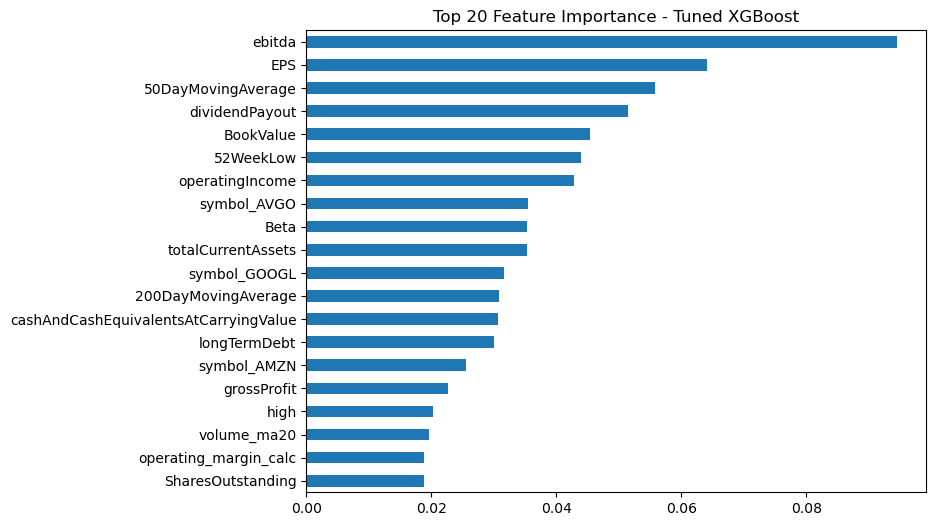

In [15]:
# Feature importance

importance = pd.Series(
    best_xgb_model.feature_importances_,
    index=X_train_balanced.columns
).sort_values(ascending=False)

print("\nTop 20 feature importances:")
print(importance.head(20))

importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Top 20 Feature Importance - Tuned XGBoost"
)
plt.show()